## Importing important libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import nibabel as nib #for loading nii files
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf #for deep learning

## Reading the metadata

In [2]:
data = pd.read_csv('../input/covid19-ct-scans/metadata.csv')
data.head()

,ct_scan,lung_mask,infection_mask,lung_and_infection_mask
0,../input/covid19-ct-scans/ct_scans/coronacases...,../input/covid19-ct-scans/lung_mask/coronacase...,../input/covid19-ct-scans/infection_mask/coron...,../input/covid19-ct-scans/lung_and_infection_m...
1,../input/covid19-ct-scans/ct_scans/coronacases...,../input/covid19-ct-scans/lung_mask/coronacase...,../input/covid19-ct-scans/infection_mask/coron...,../input/covid19-ct-scans/lung_and_infection_m...
2,../input/covid19-ct-scans/ct_scans/coronacases...,../input/covid19-ct-scans/lung_mask/coronacase...,../input/covid19-ct-scans/infection_mask/coron...,../input/covid19-ct-scans/lung_and_infection_m...
3,../input/covid19-ct-scans/ct_scans/coronacases...,../input/covid19-ct-scans/lung_mask/coronacase...,../input/covid19-ct-scans/infection_mask/coron...,../input/covid19-ct-scans/lung_and_infection_m...
4,../input/covid19-ct-scans/ct_scans/coronacases...,../input/covid19-ct-scans/lung_mask/coronacase...,../input/covid19-ct-scans/infection_mask/coron...,../input/covid19-ct-scans/lung_and_infection_m...


## Defining function for readiing .nii files

In [3]:
def read_nii(filepath):
    '''
    Reads .nii file and returns pixel array
    '''
    ct_scan = nib.load(filepath)
    array   = ct_scan.get_fdata()
    array   = np.rot90(np.array(array))
    return(array)

## Reading the chest ct scan data

In [4]:
# Read sample
sample_ct   = read_nii(data.loc[2,'ct_scan'])
sample_lung = read_nii(data.loc[2,'lung_mask'])
sample_infe = read_nii(data.loc[2,'infection_mask'])
sample_all  = read_nii(data.loc[2,'lung_and_infection_mask'])

## Plotting the sample images

Text(0.5, 1.0, 'Lung and Infection Mask')

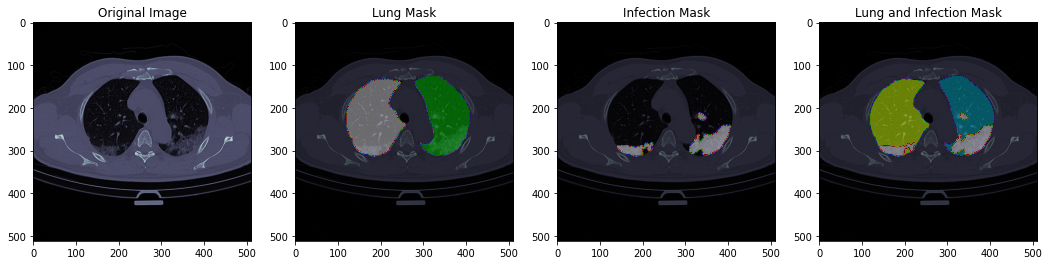

In [5]:
fig = plt.figure(figsize = (18,15))
plt.subplot(1,4,1)
plt.imshow(sample_ct[..., 150], cmap = 'bone')
plt.title('Original Image')

plt.subplot(1,4,2)
plt.imshow(sample_ct[..., 150], cmap = 'bone')
plt.imshow(sample_lung[..., 150],alpha = 0.5, cmap = 'nipy_spectral')
plt.title('Lung Mask')

plt.subplot(1,4,3)
plt.imshow(sample_ct[..., 150], cmap = 'bone')
plt.imshow(sample_infe[..., 150], alpha = 0.5, cmap = 'nipy_spectral')
plt.title('Infection Mask')

plt.subplot(1,4,4)
plt.imshow(sample_ct[..., 150], cmap = 'bone')
plt.imshow(sample_all[..., 150], alpha = 0.5, cmap = 'nipy_spectral')
plt.title('Lung and Infection Mask')

## Converting the data into array for training model

In [6]:
import numpy as np
import cv2
import random
from scipy.ndimage import rotate, shift, zoom

lungs = []
infections = []
case_ids = []
img_size = 320

# ----------- Load and Resize Data -----------
for case_index in range(len(data)):
    ct = read_nii(data['ct_scan'][case_index])
    infect = read_nii(data['infection_mask'][case_index])

    for slice_index in range(ct.shape[0]):
        lung_img = cv2.resize(ct[slice_index], dsize=(img_size, img_size)).astype('float32')
        infec_img = cv2.resize(infect[slice_index], dsize=(img_size, img_size)).astype('float32')

        lungs.append(lung_img[..., np.newaxis])
        infections.append(infec_img[..., np.newaxis])
        case_ids.append(case_index)

In [7]:
import numpy as np

# case_ids should be a NumPy array telling which case each slice belongs to
# Convert and binarize
lungs = np.array(lungs, dtype=np.float32)
infections = (np.array(infections, dtype=np.uint8) > 0.5).astype(np.uint8)
case_ids = np.array(case_ids)

## Performing test and train split

In [8]:
# ----------- Case-wise Split -----------
unique_cases = np.unique(case_ids)
train_cases = np.append(unique_cases[4:12], unique_cases[12:20])
temp_cases = unique_cases[2:4]
val_cases = unique_cases[:2]

train_mask = np.isin(case_ids, train_cases)
temp_mask = np.isin(case_ids, temp_cases)
val_mask = np.isin(case_ids, val_cases)

lung_train = lungs[train_mask]
infect_train = infections[train_mask]
lung_temp = lungs[temp_mask]
infect_temp = infections[temp_mask]
lung_test = lungs[val_mask]
infect_test = infections[val_mask]

print(f"✅ Train: {lung_train.shape[0]} slices from {len(train_cases)} cases")
print(f"✅ Validation: {lung_temp.shape[0]} slices from {len(temp_cases)} cases")
print(f"✅ Test: {lung_test.shape[0]} slices from {len(val_cases)} cases")

# ----------- Augmentation -----------
def augment_image(img, mask):
    if random.random() < 0.5:
        img = np.fliplr(img)
        mask = np.fliplr(mask)
    if random.random() < 0.5:
        img = np.flipud(img)
        mask = np.flipud(mask)

    angle = random.uniform(-15, 15)
    img = rotate(img, angle, reshape=False, order=1, mode='nearest')
    mask = rotate(mask, angle, reshape=False, order=0, mode='nearest')

    shift_val = np.random.uniform(-0.1, 0.1, size=2) * img.shape[:2]
    img = shift(img, shift=(*shift_val, 0), order=1, mode='nearest')
    mask = shift(mask, shift=(*shift_val, 0), order=0, mode='nearest')

    zoom_factor = random.uniform(0.9, 1.1)
    img = zoom(img, (zoom_factor, zoom_factor, 1), order=1)
    mask = zoom(mask, (zoom_factor, zoom_factor, 1), order=0)

    return fix_shape(img), fix_shape(mask)

def fix_shape(arr, target_size=(320, 320)):
    h, w, c = arr.shape
    th, tw = target_size
    dh = th - h
    dw = tw - w
    if dh > 0 or dw > 0:
        pad_h = (max(dh // 2, 0), max(dh - dh // 2, 0))
        pad_w = (max(dw // 2, 0), max(dw - dw // 2, 0))
        arr = np.pad(arr, (pad_h, pad_w, (0, 0)), mode='constant')
    arr = arr[:th, :tw, :]
    return arr.astype('float32')

# ----------- Apply Augmentation -----------
aug_lung_train = []
aug_infect_train = []

for i in range(len(lung_train)):
    img, mask = augment_image(lung_train[i], infect_train[i])
    aug_lung_train.append(img)
    aug_infect_train.append(mask)

lung_train = np.stack(aug_lung_train)
infect_train = np.stack(aug_infect_train)

# Final Binarization
infect_train = (infect_train > 0.5).astype(np.uint8)
infect_test = (infect_test > 0.5).astype(np.uint8)

print(f"✅ Augmented training shape: {lung_train.shape}")
print("✅ All preprocessing complete.")


✅ Train: 9143 slices from 16 cases
✅ Validation: 1024 slices from 2 cases
✅ Test: 1024 slices from 2 cases
✅ Augmented training shape: (9143, 320, 320, 1)
✅ All preprocessing complete.


In [9]:
import tensorflow as tf
from tensorflow.keras import backend as K
import numpy as np
from scipy.spatial import cKDTree

smooth = 1.0

# Binary Dice coefficient (soft - commonly used during training)
def dice_coef_infection(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Binary IoU coefficient (soft)
def iou_coef_infection(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Soft Precision
def precision_infection(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (K.sum(y_pred_f) + smooth)

# Soft Recall (Sensitivity)
def recall_infection(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (K.sum(y_true_f) + smooth)

# Soft Specificity
def specificity_infection(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    tn = K.sum((1 - y_true_f) * (1 - y_pred_f))
    fp = K.sum((1 - y_true_f) * y_pred_f)
    return (tn + smooth) / (tn + fp + smooth)

# Soft Accuracy
def accuracy_infection(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    tp = K.sum(y_true_f * y_pred_f)
    tn = K.sum((1 - y_true_f) * (1 - y_pred_f))
    total = K.cast(K.shape(y_true_f)[0], 'float32')
    return (tp + tn + smooth) / (total + smooth)

# Soft F1-score (harmonic mean of precision & recall - very close to Dice, standard in many repos)
def f1_infection(y_true, y_pred):
    precision = precision_infection(y_true, y_pred)
    recall    = recall_infection(y_true, y_pred)
    return (2. * precision * recall + smooth) / (precision + recall + smooth)

# Hausdorff Distance 95 % (robust & most commonly used in medical imaging challenges)
# Lower = better. Returns the mean HD95 over the batch.
def _calculate_hd95(y_true, y_pred):
    hd_list = []
    for i in range(y_true.shape[0]):
        # Hard threshold at 0.5 (standard for evaluation metrics)
        gt = np.squeeze(y_true[i]) > 0.5
        pred = np.squeeze(y_pred[i]) > 0.5

        gt_pts = np.argwhere(gt)
        pred_pts = np.argwhere(pred)

        # Cases with empty masks
        if gt_pts.shape[0] == 0 and pred_pts.shape[0] == 0:
            hd_list.append(0.0)
            continue
        if gt_pts.shape[0] == 0 or pred_pts.shape[0] == 0:
            hd_list.append(400.0)  # large penalty - adjust to your image diagonal if needed (e.g. ~362 for 256×256, ~724 for 512×512)
            continue

        # Directed distances
        dist_gt_to_pred = cKDTree(pred_pts).query(gt_pts)[0]
        dist_pred_to_gt = cKDTree(gt_pts).query(pred_pts)[0]

        hd95 = max(
            np.percentile(dist_gt_to_pred, 95),
            np.percentile(dist_pred_to_gt, 95)
        )
        hd_list.append(hd95)

    return np.mean(hd_list, dtype=np.float32)

def hausdorff95_infection(y_true, y_pred):
    hd = tf.numpy_function(_calculate_hd95, [y_true, y_pred], tf.float32)
    hd.set_shape(())
    return hd

# Optional: KL Divergence (you already had this)
kld = tf.keras.losses.KLDivergence()

In [10]:
from tensorflow.keras.losses import BinaryCrossentropy

def loss_f(y_true, y_pred):
    bce = BinaryCrossentropy()
    return dice_loss(y_true, y_pred) + bce(y_true, y_pred) 

def loss_e(y_true, y_pred):
    bce = BinaryCrossentropy()
    return dice_loss(y_true, y_pred)  + kld(y_true, y_pred)
    
def dice_loss(y_true, y_pred):
    return 1. - dice_coef_infection(y_true, y_pred)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Multiply, Conv2D, DepthwiseConv2D, Dense, Flatten, MaxPooling2D, UpSampling2D, concatenate, Activation, LayerNormalization, Add, Dropout, Conv2DTranspose, multiply, Reshape, GlobalAveragePooling2D, Permute, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Concatenate

def activation_block(x):
    x = Activation("gelu")(x)
    return LayerNormalization()(x)

def conv_stem(x, filters: int, patch_size: int):
    x = Conv2D(filters, kernel_size=patch_size,padding='same', strides=patch_size)(x)
    return activation_block(x)

def vector_block(xyz, cmf, red):
    # red means reduction
    # cmf means filters, denotes vector size
    opt1 = conv_stem(xyz, cmf, red)
    opt2 = conv_stem(xyz, cmf, red)
    
    o1 = GlobalAveragePooling2D()(opt1)
    o2 = GlobalAveragePooling2D()(opt2)

    o5 = concatenate([o1, o2], -1)
    return o5

def mlp_feature(vect, cmf):
    oo = Flatten()(vect)
    o6 = Dense(cmf, activation='gelu')(oo)
    o6 = Dropout(0.2)(o6)
    o6 = Dense(cmf * 2, activation='gelu')(o6)

    o6 = Reshape((1, cmf * 2))(o6)
    o7 = Permute((2, 1))(o6)

    o8 = multiply([o6, o7])
    
    o8 = Lambda(lambda x: tf.expand_dims(x, -1))(o8)
    
    o8 = Reshape((cmf, cmf, 4))(o8)

    return o8

def frz_block(xyz):
    shape = xyz.shape
    a1, a2, a3, a4 = shape[0], shape[1], shape[2], shape[3]
    cmf = a2
    o5 = vector_block(xyz, cmf, 5)
    o7 = mlp_feature(o5, cmf)

    o7 = concatenate([o7, xyz, o7], -1)
    return o7

def up_frz(x1, x2, n_filters):
    # Upsample x1 using Conv2DTranspose
    x1 = Conv2DTranspose(n_filters * 4, 3, strides=2, activation='gelu', padding="same")(x1)
    
    # Apply Conv2D to x2
    x2 = Conv2D(n_filters * 2, 3, activation='gelu', padding="same")(x2)
    
    # Apply attention mechanism
    x = concatenate([x1, x2])
    
    # Apply Dropout for regularization
    x = Dropout(0.3)(x)
    
    return x

In [12]:
from tensorflow.keras.layers import Layer,AveragePooling2D, InputSpec
# Keras
from tensorflow import keras
from keras.models import Model
from keras.layers import Input
from keras.layers.convolutional import Conv2D, Conv2DTranspose
from keras.layers.pooling import MaxPooling2D
from keras.layers.merge import concatenate
from keras.losses import binary_crossentropy
from keras.callbacks import Callback, ModelCheckpoint, EarlyStopping
from keras.models import load_model, save_model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import add
from tensorflow.keras.layers import DepthwiseConv2D
from tensorflow.keras import regularizers

class BilinearUpSampling2D(Layer):
    def __init__(self, target_shape=None, factor=None, data_format=None, **kwargs):
        # conmpute dataformat
        if data_format is None:
            data_format = K.image_data_format()
        assert data_format in {"channels_last", "channels_first"}

        self.data_format = data_format
        self.input_spec = [InputSpec(ndim=4)]
        self.target_shape = target_shape
        self.factor = factor
        if self.data_format == "channels_first":
            self.target_size = (target_shape[2], target_shape[3])
        elif self.data_format == "channels_last":
            self.target_size = (target_shape[1], target_shape[2])
        super(BilinearUpSampling2D, self).__init__(**kwargs)

    def compute_output_shape(self, input_shape):
        if self.data_format == "channels_last":
            return (
                input_shape[0],
                self.target_size[0],
                self.target_size[1],
                input_shape[3],
            )
        else:
            return (
                input_shape[0],
                input_shape[1],
                self.target_size[0],
                self.target_size[1],
            )

    def call(self, inputs):
        return K.resize_images(inputs, self.factor, self.factor, self.data_format)

    def get_config(self):
        config = {"target_shape": self.target_shape, "data_format": self.data_format}
        base_config = super(BilinearUpSampling2D, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


def identity_block(
    input_tensor,
    kernel_size,
    filters,
    stage,
    block,
    dilation_rate=1,
    multigrid=[1, 2, 1],
    use_se=True,
):
    # conv filters
    filters1, filters2, filters3 = filters

    # compute dataformat
    if K.image_data_format() == "channels_last":
        bn_axis = 3
    else:
        bn_axis = 1

    # layer names
    conv_name_base = "res" + str(stage) + block + "_branch"
    bn_name_base = "bn" + str(stage) + block + "_branch"

    # dilated rate
    if dilation_rate < 2:
        multigrid = [1, 1, 1]

    # forward
    x = Conv2D(
        filters1,
        (1, 1),
        name=conv_name_base + "2a",
        dilation_rate=dilation_rate * multigrid[0],
    )(input_tensor)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + "2a")(x)
    x = Activation("relu")(x)

    x = Conv2D(
        filters2,
        kernel_size,
        padding="same",
        name=conv_name_base + "2b",
        dilation_rate=dilation_rate * multigrid[1],
    )(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + "2b")(x)
    x = Activation("relu")(x)

    x = Conv2D(
        filters3,
        (1, 1),
        name=conv_name_base + "2c",
        dilation_rate=dilation_rate * multigrid[2],
    )(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + "2c")(x)

    # stage 5 after squeeze and excinttation layer
    if use_se and stage < 5:
        se = _squeeze_excite_block(x, filters3, k=1, name=conv_name_base + "_se")
        x = multiply([x, se])
    x = add([x, input_tensor])
    x = Activation("relu")(x)

    return x


def _conv(**conv_params):
    # conv params
    filters = conv_params["filters"]
    kernel_size = conv_params["kernel_size"]
    strides = conv_params.setdefault("strides", (1, 1))
    dilation_rate = conv_params.setdefault("dilation_rate", (1, 1))
    kernel_initializer = conv_params.setdefault("kernel_initializer", "he_normal")
    padding = conv_params.setdefault("padding", "same")

    def f(input):
        conv = Conv2D(
            filters=filters,
            kernel_size=kernel_size,
            strides=strides,
            padding=padding,
            dilation_rate=dilation_rate,
            kernel_initializer=kernel_initializer,
            activation="linear",
        )(input)
        return conv

    return f


# Atrous Spatial Pyramid Pooling block
def aspp_block(
    x, num_filters=256, rate_scale=1, output_stride=16, input_shape=(512, 512, 3)
):
    # compute dataformat
    if K.image_data_format() == "channels_last":
        bn_axis = 3
    else:
        bn_axis = 1

    # forward
    conv3_3_1 = ZeroPadding2D(padding=(6 * rate_scale, 6 * rate_scale))(x)
    conv3_3_1 = _conv(
        filters=num_filters,
        kernel_size=(3, 3),
        dilation_rate=(6 * rate_scale, 6 * rate_scale),
        padding="valid",
        block="assp_3_3_1_%s" % output_stride,
    )(conv3_3_1)
    conv3_3_1 = BatchNormalization(axis=bn_axis, name="bn_3_3_1_%s" % output_stride)(
        conv3_3_1
    )

    conv3_3_2 = ZeroPadding2D(padding=(12 * rate_scale, 12 * rate_scale))(x)
    conv3_3_2 = _conv(
        filters=num_filters,
        kernel_size=(3, 3),
        dilation_rate=(12 * rate_scale, 12 * rate_scale),
        padding="valid",
        block="assp_3_3_2_%s" % output_stride,
    )(conv3_3_2)
    conv3_3_2 = BatchNormalization(axis=bn_axis, name="bn_3_3_2_%s" % output_stride)(
        conv3_3_2
    )

    conv3_3_3 = ZeroPadding2D(padding=(18 * rate_scale, 18 * rate_scale))(x)
    conv3_3_3 = _conv(
        filters=num_filters,
        kernel_size=(3, 3),
        dilation_rate=(18 * rate_scale, 18 * rate_scale),
        padding="valid",
        block="assp_3_3_3_%s" % output_stride,
    )(conv3_3_3)
    conv3_3_3 = BatchNormalization(axis=bn_axis, name="bn_3_3_3_%s" % output_stride)(
        conv3_3_3
    )

    conv1_1 = _conv(
        filters=num_filters,
        kernel_size=(1, 1),
        padding="same",
        block="assp_1_1_%s" % output_stride,
    )(x)
    conv1_1 = BatchNormalization(axis=bn_axis, name="bn_1_1_%s" % output_stride)(
        conv1_1
    )

    # channel merge
    y = merge(
        [conv3_3_1, conv3_3_2, conv3_3_3, conv1_1],
        # global_feat,
        mode="concat",
        concat_axis=3,
    )

    # y = _conv_bn_relu(filters=1, kernel_size=(1, 1),padding='same')(y)
    y = _conv(
        filters=256,
        kernel_size=(1, 1),
        padding="same",
        block="assp_out_%s" % output_stride,
    )(y)
    y = BatchNormalization(axis=bn_axis, name="bn_out_%s" % output_stride)(y)

    return y


# residual module
def conv_block(
    input_tensor,
    kernel_size,
    filters,
    stage,
    block,
    strides=(2, 2),
    dilation_rate=1,
    multigrid=[1, 2, 1],
    use_se=True,
):
    # conv filters
    filters1, filters2, filters3 = filters

    # compute dataformat
    if K.image_data_format() == "channels_last":
        bn_axis = 3
    else:
        bn_axis = 1
    conv_name_base = "res" + str(stage) + block + "_branch"
    bn_name_base = "bn" + str(stage) + block + "_branch"

    # dailated rate
    if dilation_rate > 1:
        strides = (1, 1)
    else:
        multigrid = [1, 1, 1]

    # forward
    x = Conv2D(
        filters1,
        (1, 1),
        strides=strides,
        name=conv_name_base + "2a",
        dilation_rate=dilation_rate * multigrid[0],
    )(input_tensor)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + "2a")(x)
    x = Activation("relu")(x)

    x = Conv2D(
        filters2,
        kernel_size,
        padding="same",
        name=conv_name_base + "2b",
        dilation_rate=dilation_rate * multigrid[1],
    )(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + "2b")(x)
    x = Activation("relu")(x)

    x = Conv2D(
        filters3,
        (1, 1),
        name=conv_name_base + "2c",
        dilation_rate=dilation_rate * multigrid[2],
    )(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + "2c")(x)

    shortcut = Conv2D(filters3, (1, 1), strides=strides, name=conv_name_base + "1")(
        input_tensor
    )
    shortcut = BatchNormalization(axis=bn_axis, name=bn_name_base + "1")(shortcut)

    # stage after 5 squeeze and excittation
    if use_se and stage < 5:
        se = _squeeze_excite_block(x, filters3, k=1, name=conv_name_base + "_se")
        x = multiply([x, se])
    x = add([x, shortcut])
    x = Activation("relu")(x)

    return x


def duc(x, factor=8, output_shape=(512, 512, 1)):
    if K.image_data_format() == "channels_last":
        bn_axis = 3
    else:
        bn_axis = 1
    H, W, c, r = output_shape[0], output_shape[1], output_shape[2], factor
    h = H / r
    w = W / r
    x = Conv2D(c * r * r, (3, 3), padding="same", name="conv_duc_%s" % factor)(x)
    x = BatchNormalization(axis=bn_axis, name="bn_duc_%s" % factor)(x)
    x = Activation("relu")(x)
    x = Permute((3, 1, 2))(x)
    x = Reshape((c, r, r, h, w))(x)
    x = Permute((1, 4, 2, 5, 3))(x)
    x = Reshape((c, H, W))(x)
    x = Permute((2, 3, 1))(x)

    return x


import tensorflow as tf

def Interp(x, shape):
    new_height, new_width = map(int, shape)
    return tf.image.resize(x, [new_height, new_width], method='bilinear', antialias=True)



def interp_block(
    x, num_filters=512, level=1, input_shape=(512, 512, 3), output_stride=16
):
    """ interpolation block """
    feature_map_shape = (input_shape[0] / output_stride, input_shape[1] / output_stride)

    # compute dataformat
    if K.image_data_format() == "channels_last":
        bn_axis = 3
    else:
        bn_axis = 1

    scale = 5

    kernel = (level * scale, level * scale)
    strides = (level * scale, level * scale)
    global_feat = AveragePooling2D(
        kernel, strides=strides, name="pool_level_%s_%s" % (level, output_stride)
    )(x)
    global_feat = _conv(
        filters=num_filters,
        kernel_size=(1, 1),
        padding="same",
        name="conv_level_%s_%s" % (level, output_stride),
    )(global_feat)
    global_feat = BatchNormalization(
        axis=bn_axis, name="bn_level_%s_%s" % (level, output_stride)
    )(global_feat)
    global_feat = Lambda(Interp, arguments={"shape": feature_map_shape})(global_feat)

    return global_feat


# squeeze and excitation function
def _squeeze_excite_block(input, filters, k=1, name=None):
    init = input
    if K.image_data_format() == "channels_last":
        se_shape = (1, 1, filters * k)
    else:
        se_shape = (filters * k, 1, 1)

    se = GlobalAveragePooling2D()(init)
    se = Reshape(se_shape)(se)
    se = Dense(
        (filters * k) // 16,
        activation="relu",
        kernel_initializer="he_normal",
        use_bias=False,
        name=name + "_fc1",
    )(se)
    se = Dense(
        filters * k,
        activation="sigmoid",
        kernel_initializer="he_normal",
        use_bias=False,
        name=name + "_fc2",
    )(se)
    return se


def pyramid_pooling_module(
    x, num_filters=512, input_shape=(512, 512, 3), output_stride=16, levels=[6, 3, 2, 1]
):
    """ pyramid pooling function """

    # compute data format
    if K.image_data_format() == "channels_last":
        bn_axis = 3
    else:
        bn_axis = 1

    pyramid_pooling_blocks = [x]
    for level in levels:
        pyramid_pooling_blocks.append(
            interp_block(
                x,
                num_filters=num_filters,
                level=level,
                input_shape=input_shape,
                output_stride=output_stride,
            )
        )

    y = concatenate(pyramid_pooling_blocks)
    # y = merge(pyramid_pooling_blocks, mode='concat', concat_axis=3)
    y = _conv(
        filters=num_filters,
        kernel_size=(3, 3),
        padding="same",
        block="pyramid_out_%s" % output_stride,
    )(y)
    y = BatchNormalization(axis=bn_axis, name="bn_pyramid_out_%s" % output_stride)(y)
    y = Activation("relu")(y)

    return y


def crop_deconv(
    classes,
    scale=1,
    kernel_size=(4, 4),
    strides=(2, 2),
    crop_offset="centered",
    weight_decay=0.0,
    block_name="featx",
):
    def f(x, y):
        def scaling(xx, ss=1):
            return xx * ss

        scaled = Lambda(
            scaling, arguments={"ss": scale}, name="scale_{}".format(block_name)
        )(x)
        score = Conv2D(
            filters=classes,
            kernel_size=(1, 1),
            activation="linear",
            kernel_initializer="he_normal",
            name="score_{}".format(block_name),
        )(scaled)

        if y is None:
            upscore = Conv2DTranspose(
                filters=classes,
                kernel_size=kernel_size,
                strides=strides,
                padding="valid",
                kernel_initializer="he_normal",
                use_bias=False,
                name="upscore_{}".format(block_name),
            )(score)
        else:
            crop = CroppingLike2D(
                target_shape=K.int_shape(y),
                offset=crop_offset,
                name="crop_{}".format(block_name),
            )(score)
            merge = add([y, crop])
            upscore = Conv2DTranspose(
                filters=classes,
                kernel_size=kernel_size,
                strides=strides,
                padding="valid",
                kernel_initializer="he_normal",
                use_bias=False,
                name="upscore_{}".format(block_name),
            )(merge)
        return upscore

    return f


def PSPNet50(
    input_shape=(512, 512, 3),
    n_labels=20,
    output_stride=16,
    num_blocks=4,
    multigrid=[1, 1, 1],
    levels=[6, 3, 2, 1],
    use_se=True,
    output_mode="sigmoid",
    upsample_type="deconv",
):

    # Input shape
    img_input = Input(shape=input_shape)

    # compute input shape
    if K.image_data_format() == "channels_last":
        bn_axis = 3
    else:
        bn_axis = 1

    x = Conv2D(64, (7, 7), strides=(2, 2), padding="same", name="conv1")(img_input)
    x = BatchNormalization(axis=bn_axis, name="bn_conv1")(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = conv_block(
        x, 3, [64, 64, 256], stage=2, block="a", strides=(1, 1), use_se=use_se
    )
    x = identity_block(x, 3, [64, 64, 256], stage=2, block="b", use_se=use_se)
    x = identity_block(x, 3, [64, 64, 256], stage=2, block="c", use_se=use_se)

    x = conv_block(x, 3, [128, 128, 512], stage=3, block="a", use_se=use_se)
    x = identity_block(x, 3, [128, 128, 512], stage=3, block="b", use_se=use_se)
    x = identity_block(x, 3, [128, 128, 512], stage=3, block="c", use_se=use_se)
    x = identity_block(x, 3, [128, 128, 512], stage=3, block="d", use_se=use_se)

    if output_stride == 8:
        rate_scale = 2
    elif output_stride == 16:
        rate_scale = 1

    x = conv_block(
        x,
        3,
        [256, 256, 1024],
        stage=4,
        block="a",
        dilation_rate=1 * rate_scale,
        multigrid=multigrid,
        use_se=use_se,
    )
    x = identity_block(
        x,
        3,
        [256, 256, 1024],
        stage=4,
        block="b",
        dilation_rate=1 * rate_scale,
        multigrid=multigrid,
        use_se=use_se,
    )
    x = identity_block(
        x,
        3,
        [256, 256, 1024],
        stage=4,
        block="c",
        dilation_rate=1 * rate_scale,
        multigrid=multigrid,
        use_se=use_se,
    )
    x = identity_block(
        x,
        3,
        [256, 256, 1024],
        stage=4,
        block="d",
        dilation_rate=1 * rate_scale,
        multigrid=multigrid,
        use_se=use_se,
    )
    x = identity_block(
        x,
        3,
        [256, 256, 1024],
        stage=4,
        block="e",
        dilation_rate=1 * rate_scale,
        multigrid=multigrid,
        use_se=use_se,
    )
    x = identity_block(
        x,
        3,
        [256, 256, 1024],
        stage=4,
        block="f",
        dilation_rate=1 * rate_scale,
        multigrid=multigrid,
        use_se=use_se,
    )

    init_rate = 2
    for block in range(4, num_blocks + 1):
        if block == 4:
            block = ""
        x = conv_block(
            x,
            3,
            [512, 512, 2048],
            stage=5,
            block="a%s" % block,
            dilation_rate=init_rate * rate_scale,
            multigrid=multigrid,
            use_se=use_se,
        )
        x = identity_block(
            x,
            3,
            [512, 512, 2048],
            stage=5,
            block="b%s" % block,
            dilation_rate=init_rate * rate_scale,
            multigrid=multigrid,
            use_se=use_se,
        )
        x = identity_block(
            x,
            3,
            [512, 512, 2048],
            stage=5,
            block="c%s" % block,
            dilation_rate=init_rate * rate_scale,
            multigrid=multigrid,
            use_se=use_se,
        )
        init_rate *= 2

    x = pyramid_pooling_module(
        x,
        num_filters=512,
        input_shape=input_shape,
        output_stride=output_stride,
        levels=levels,
    )

    # x = merge([
    #         x1,
    #         x2,
    #         ], mode='concat', concat_axis=3)

    # upsample_type
    if upsample_type == "duc":
        x = duc(
            x,
            factor=output_stride,
            output_shape=(input_shape[0], input_shape[1], n_labels),
        )
        out = _conv(
            filters=n_labels,
            kernel_size=(1, 1),
            padding="same",
            block="out_duc_%s" % output_stride,
        )(x)

    elif upsample_type == "bilinear":
        x = _conv(
            filters=n_labels,
            kernel_size=(1, 1),
            padding="same",
            block="out_bilinear_%s" % output_stride,
        )(x)
        out = BilinearUpSampling2D(
            (n_labels, input_shape[0], input_shape[1]), factor=output_stride
        )(x)

    elif upsample_type == "deconv":
        out = Conv2DTranspose(
            filters=n_labels,
            kernel_size=(output_stride * 2, output_stride * 2),
            strides=(output_stride, output_stride),
            padding="same",
            kernel_initializer="he_normal",
            kernel_regularizer=None,
            use_bias=False,
            name="upscore_{}".format("out"),
        )(x)

    out = Reshape(
        (input_shape[0], input_shape[1], n_labels),
        input_shape=(input_shape[0], input_shape[1], n_labels),
    )(out)
    # default "softmax"
    out = Activation(output_mode)(out)

    model = Model(inputs=img_input, outputs=out)

    return model

model = PSPNet50(
    input_shape=(320, 320, 1),
    n_labels=1,
    output_stride=8,
    use_se=False,
    output_mode='sigmoid',
    upsample_type='deconv',
    levels=[6, 3, 2, 1],  # smaller levels to reduce kernel size
)

In [13]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(model):
    """Calculate Floating Point Operations (FLOPs) of a Keras model in TensorFlow 2.x."""
    # Convert Keras model to a TensorFlow function
    concrete_func = tf.function(lambda inputs: model(inputs))
    concrete_func = concrete_func.get_concrete_function(
        tf.TensorSpec([1] + list(model.input_shape[1:]), model.input.dtype)
    )

    # Convert to frozen graph
    frozen_func, _ = convert_variables_to_constants_v2_as_graph(concrete_func)

    # Compute FLOPs
    flops = tf.compat.v1.profiler.profile(
        frozen_func.graph,
        options=tf.compat.v1.profiler.ProfileOptionBuilder.float_operation(),
    )

    return flops.total_float_ops

# Compute FLOPs
flops = get_flops(model)
print(f"Total FLOPs: {flops / 1e9:.2f} GFLOPs")  # Convert to GFLOPs

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss=loss_f, metrics=[dice_coef_infection, iou_coef_infection, precision_infection, recall_infection, hausdorff95_infection, specificity_infection, accuracy_infection, f1_infection])

# Model summary
model.summary()

Total FLOPs: 138.22 GFLOPs
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 320, 320, 1) 0                                            
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 160, 160, 64) 3200        input_1[0][0]                    
__________________________________________________________________________________________________
bn_conv1 (BatchNormalization)   (None, 160, 160, 64) 256         conv1[0][0]                      
__________________________________________________________________________________________________
activation (Activation)         (None, 160, 160, 64) 0           bn_conv1[0][0]                   
___________________________________________________________________

In [14]:
# Install required packages
!pip install openpyxl

# Imports
import openpyxl  # required for reading .xlsx files
import pandas as pd
import tensorflow as tf
import os
import shutil
from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau

# File paths
checkpoint_filepath = '/kaggle/working/checkpoint.h5.keras'
metrics_file = '/kaggle/working/training_metrics.xlsx'
pre_checkpoint_filepath = '/kaggle/input/pspnet-covid19-finalrun1/checkpoint.h5.keras'
pre_metrics_file = '/kaggle/input/pspnet-covid19-finalrun1/training_metrics.xlsx'

# Restore checkpoint and metrics if available
if os.path.exists(pre_checkpoint_filepath):
    shutil.copy(pre_checkpoint_filepath, checkpoint_filepath)
    print(f"Restored checkpoint from: {pre_checkpoint_filepath}")

if os.path.exists(pre_metrics_file):
    shutil.copy(pre_metrics_file, metrics_file)
    print(f"Restored metrics file from: {pre_metrics_file}")

# Load last epoch
def load_last_epoch():
    if os.path.exists(metrics_file):
        try:
            df = pd.read_excel(metrics_file, engine='openpyxl')
            if not df.empty and 'epoch' in df.columns:
                return df['epoch'].iloc[-1] + 1
        except Exception as e:
            print(f"⚠️ Could not read metrics file: {e}")
    return 0

last_epoch = load_last_epoch()

# Get best validation loss from previous runs
def get_best_val_loss():
    if os.path.exists(metrics_file):
        try:
            df = pd.read_excel(metrics_file, engine='openpyxl')
            if 'val_loss' in df.columns and not df['val_loss'].isnull().all():
                return df['val_loss'].min()
        except Exception as e:
            print(f"⚠️ Could not read val_loss from metrics file: {e}")
    return float('inf')

best_val_loss = get_best_val_loss()

# Custom model checkpoint
class CustomModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath
        self.best_loss = best_val_loss

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('val_loss')
        if current_loss is not None and current_loss < self.best_loss:
            self.best_loss = current_loss
            self.model.save(self.filepath)
            print(f"✅ Model saved at epoch {epoch + 1} with val_loss: {current_loss:.4f}")

# === Learning Rate Schedule ===
def lr_schedule(epoch, lr):
    return 1e-4 if epoch >= 1 else lr

lr_scheduler = LearningRateScheduler(lr_schedule, verbose=1)

# Logger for Excel
class MetricsLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        df_new = pd.DataFrame([{**logs, 'epoch': epoch}])
        try:
            if os.path.exists(metrics_file):
                df = pd.read_excel(metrics_file, engine='openpyxl')
                df = pd.concat([df, df_new], ignore_index=True)
            else:
                df = df_new
            df.to_excel(metrics_file, index=False, engine='openpyxl')
        except Exception as e:
            print(f"⚠️ Failed to log metrics: {e}")

# Early stopping with patience and saving best weights
class CustomEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, patience=20):
        super().__init__()
        self.patience = patience
        self.wait = 0
        self.best_loss = best_val_loss

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('val_loss')
        if current_loss is None:
            return
        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.wait = 0
            self.model.save_weights(checkpoint_filepath)
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"🛑 Early stopping at epoch {epoch + 1}")
                self.model.stop_training = True


# Final callbacks list
callbacks = [
    CustomModelCheckpoint(filepath=checkpoint_filepath),
    MetricsLogger(),
    lr_scheduler,
    CustomEarlyStopping(patience=20)
]


     |████████████████████████████████| 251 kB 13.2 MB/s eta 0:00:01
Restored checkpoint from: /kaggle/input/pspnet-covid19-finalrun1/checkpoint.h5.keras
Restored metrics file from: /kaggle/input/pspnet-covid19-finalrun1/training_metrics.xlsx


## Training the model

In [15]:
import time
import os
import pandas as pd
import numpy as np
from tensorflow.keras.utils import Sequence
from tensorflow.keras.models import load_model

EPOCHS = 100

# Record the start time
start_time = time.time()

# === Load last completed epoch from metrics file ===
def load_last_epoch():
    if os.path.exists(pre_metrics_file):
        try:
            df = pd.read_excel(pre_metrics_file, engine='openpyxl')
            if not df.empty and 'epoch' in df.columns:
                return int(df['epoch'].iloc[-1]) + 1
        except Exception as e:
            print(f"⚠️ Failed to read metrics file: {e}")
    return 0

last_epoch = load_last_epoch()

# === Load pretrained weights if available ===
if os.path.exists(pre_checkpoint_filepath):
    print("✅ Checkpoint found. Loading pretrained weights...")
    model.load_weights(pre_checkpoint_filepath)
    print(f"🔁 Resuming training from epoch {last_epoch}")
else:
    print("🆕 No checkpoint found. Starting training from scratch.")
    last_epoch = 0

# === Prepare input and label tensors ===
lung_train = np.asarray(lung_train, dtype=np.float16)
infect_train = np.asarray(infect_train, dtype=np.uint8)

lung_temp = np.asarray(lung_temp, dtype=np.float16)
infect_temp = np.asarray(infect_temp, dtype=np.uint8)

lung_test = np.asarray(lung_test, dtype=np.float16)
infect_test = np.asarray(infect_test, dtype=np.uint8)

# === Data Generator ===
class LungDataGenerator(Sequence):
    def __init__(self, X, Y, batch_size=8, shuffle=True):
        self.X = X
        self.Y = Y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        batch_ids = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = self.X[batch_ids]
        Y_batch = self.Y[batch_ids]
        return np.asarray(X_batch, dtype=np.float16), np.asarray(Y_batch, dtype=np.uint8)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# === Create generators ===
train_gen = LungDataGenerator(lung_train, infect_train, batch_size=8)
temp_gen = LungDataGenerator(lung_temp, infect_temp, batch_size=8, shuffle=False)
val_gen = LungDataGenerator(lung_test, infect_test, batch_size=8, shuffle=False)

# === Train the model ===
history = model.fit(
    train_gen,
    validation_data=temp_gen,
    epochs=EPOCHS,
    initial_epoch=last_epoch,
    callbacks=callbacks
)

# === Timing info ===
end_time = time.time()
total_time = end_time - start_time
print(f"✅ Total training time: {total_time:.2f} seconds ({total_time / 60:.2f} minutes)")


✅ Checkpoint found. Loading pretrained weights...
🔁 Resuming training from epoch 52
Epoch 53/100

Epoch 00053: LearningRateScheduler reducing learning rate to 0.0001.
1143/1143 [==============================] - 648s 555ms/step - loss: 0.3128 - dice_coef_infection: 0.7074 - iou_coef_infection: 0.5765 - precision_infection: 0.7335 - recall_infection: 0.7337 - hausdorff95_infection: 38.5260 - specificity_infection: 0.9981 - accuracy_infection: 0.9962 - f1_infection: 0.8423 - val_loss: 0.4202 - val_dice_coef_infection: 0.6358 - val_iou_coef_infection: 0.6178 - val_precision_infection: 0.9837 - val_recall_infection: 0.6200 - val_hausdorff95_infection: 120.8549 - val_specificity_infection: 0.9997 - val_accuracy_infection: 0.9945 - val_f1_infection: 0.8171
Epoch 54/100

Epoch 00054: LearningRateScheduler reducing learning rate to 0.0001.
1143/1143 [==============================] - 630s 551ms/step - loss: 0.3290 - dice_coef_infection: 0.6914 - iou_coef_infection: 0.5604 - precision_infection

## Plotting the performance metrics

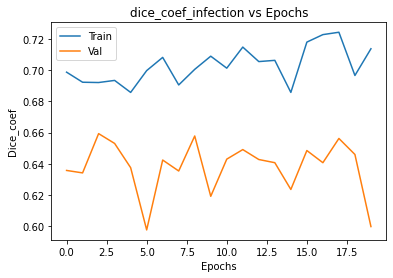

In [16]:
plt.plot(history.history['dice_coef_infection'])
plt.plot(history.history['val_dice_coef_infection'])
plt.title('dice_coef_infection vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Dice_coef')
plt.legend(['Train', 'Val'], loc = 'upper left')
plt.show()

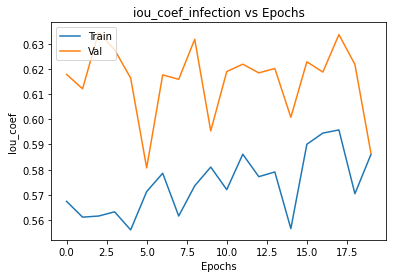

In [17]:
plt.plot(history.history['iou_coef_infection'])
plt.plot(history.history['val_iou_coef_infection'])
plt.title('iou_coef_infection vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Iou_coef')
plt.legend(['Train', 'Val'], loc = 'upper left')
plt.show()

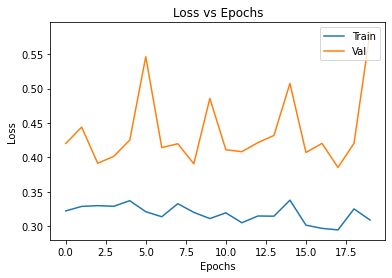

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc = 'upper right')
plt.show()

## Using our trained model for prediction

In [19]:
import numpy as np
import time

# Start timer (high precision)
start_time = time.perf_counter()

# Evaluate the model on the validation generator
results = model.evaluate(val_gen, verbose=1)

# End timer
end_time = time.perf_counter()

# Calculate evaluation time
eval_time = end_time - start_time

# Print metric names with results
print("\n===== Validation Metrics =====")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.6f}")

print(f"\nEvaluation Time: {eval_time:.8f} seconds\n")


128/128 [==============================] - 27s 213ms/step - loss: 0.4631 - dice_coef_infection: 0.6422 - iou_coef_infection: 0.6194 - precision_infection: 0.9689 - recall_infection: 0.6292 - hausdorff95_infection: 119.0478 - specificity_infection: 0.9998 - accuracy_infection: 0.9955 - f1_infection: 0.8209

===== Validation Metrics =====
loss: 0.463139
dice_coef_infection: 0.642220
iou_coef_infection: 0.619375
precision_infection: 0.968875
recall_infection: 0.629237
hausdorff95_infection: 119.047798
specificity_infection: 0.999802
accuracy_infection: 0.995466
f1_infection: 0.820872

Evaluation Time: 27.29150568 seconds



In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Run inference if not already done
predicted = model.predict(lung_test)

# Selected indices to visualize (744 as 1st, 280 as 2nd, 230 as 3rd)
selected_indices = [744, 280, 230]
n_samples = len(selected_indices)

# Mapping indices to custom names
name_mapping = {
    0: ("Image1_Covid", "GT1_Covid", "Predict1_Covid_DSEG_Unet"),  # Index 744
    1: ("Image2_Covid", "GT2_Covid", "Predict2_Covid_DSEG_Unet"),  # Index 280
    2: ("Image3_Covid", "GT3_Covid", "Predict3_Covid_DSEG_Unet")   # Index 230
}

# Plot
for j, i in enumerate(selected_indices):
    lung_img = lung_test[i][..., 0].astype(np.float32)
    gt_infect = (infect_test[i][..., 0] > 0.5).astype(np.float32)
    pred_infect = predicted[i][..., 0].astype(np.float32)

    # Normalize lung image
    if lung_img.max() > lung_img.min():
        lung_img = (lung_img - lung_img.min()) / (lung_img.max() - lung_img.min())
    lung_img = np.clip(lung_img, 0, 1)
    pred_infect = np.clip(pred_infect, 0, 1)

    # Get custom names for this index
    input_name, gt_name, pred_name = name_mapping[j]

    # Save Original Lung
    fig, ax = plt.subplots(figsize=(320/300, 320/300), dpi=300)
    ax.imshow(lung_img, cmap='bone')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.savefig(f'{input_name}.jpeg', dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    # Save Ground Truth Infection
    fig, ax = plt.subplots(figsize=(320/300, 320/300), dpi=300)
    ax.imshow(lung_img, cmap='bone')
    ax.imshow(gt_infect, cmap='Reds', alpha=0.6)
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.savefig(f'{gt_name}.jpeg', dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    # Save Predicted Infection
    fig, ax = plt.subplots(figsize=(320/300, 320/300), dpi=300)
    ax.imshow(lung_img, cmap='bone')
    ax.imshow(pred_infect, cmap='Reds', alpha=0.6)
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.savefig(f'{pred_name}.jpeg', dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

print("Separate JPEG files saved for input images (Image1_Covid, Image2_Covid, Image3_Covid), "
      "ground truths (GT1_Covid, GT2_Covid, GT3_Covid), and predictions "
      "(Predict1_Covid_DSEG_Unet, Predict2_Covid_DSEG_Unet, Predict3_Covid_DSEG_Unet).")

Separate JPEG files saved for input images (Image1_Covid, Image2_Covid, Image3_Covid), ground truths (GT1_Covid, GT2_Covid, GT3_Covid), and predictions (Predict1_Covid_DSEG_Unet, Predict2_Covid_DSEG_Unet, Predict3_Covid_DSEG_Unet).
